## Business Usecase

At a retail shopping mall we are tasked with performing an analysis to better understand the mall's customers. To this end we would like to do some customer segmentation using provided customer data. A great candidate for this task is the K-means Clustering method, an unsupervised machine learning technique that will seek patterns in the data to identify clusters (segments) of similar customers. We can then provide the insights of this analysis to management, in order to inform the design of targeted marketing strategies, and improve engagement and sales.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [ ]:
os.environ["LOKY_MAX_CPU_COUNT"] = "12"

## Data Loading, Exploration, and Preprocessing

This dataset comprises `Gender`, `Age`, `Annual Income` in thousands of dollars, and `Spending Score` for 200 mall customers. Let's take a look at some summary statistics of the data.

In [4]:
mall_cust_data = pd.read_csv('Mall_Customers.csv')
mall_cust_data.info()
mall_cust_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
mall_cust_data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Let's plot the distributions of our three numerical variables

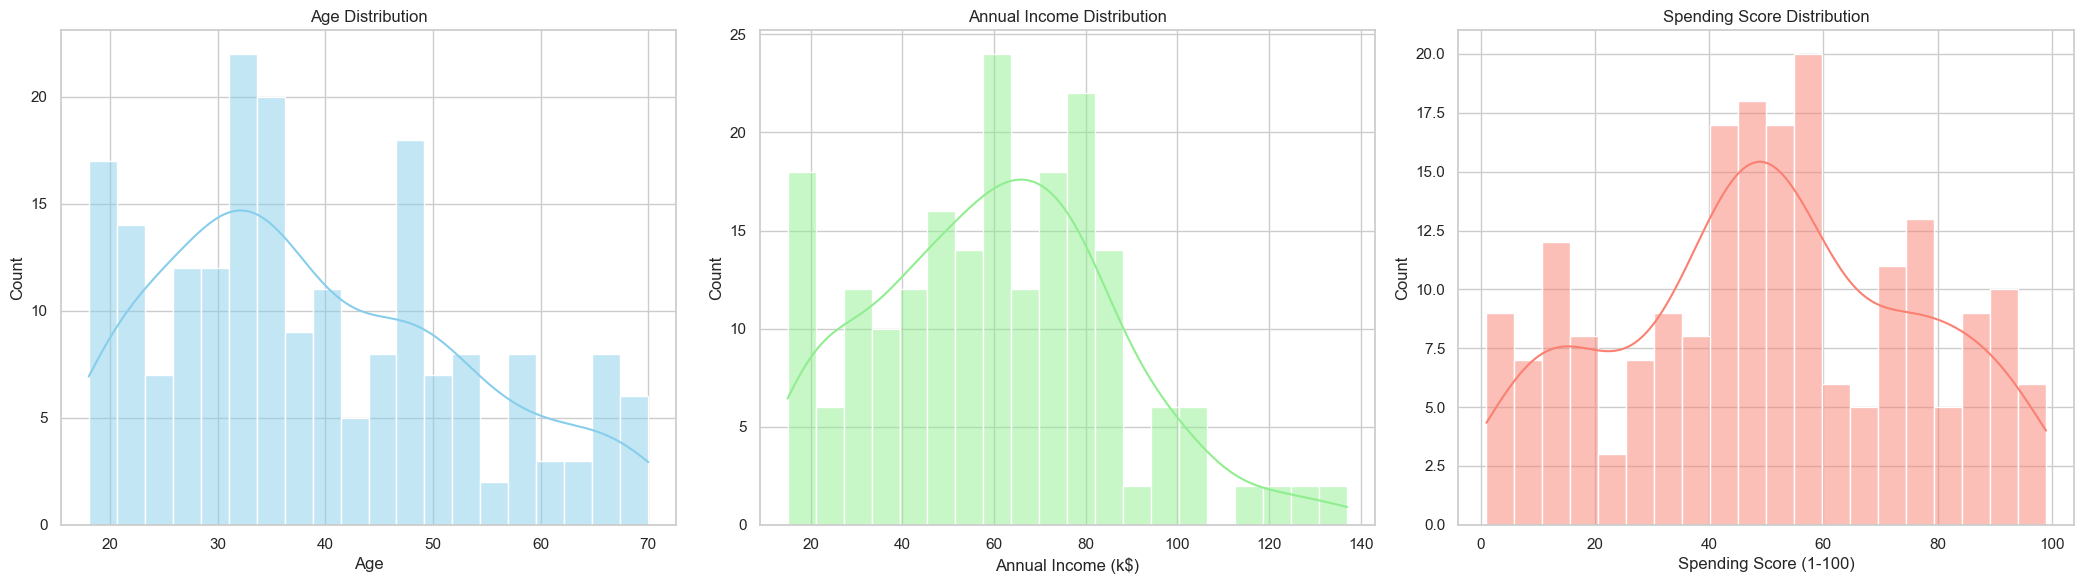

In [6]:
# Set overall style
sns.set(style="whitegrid")

# Define the figure and axes
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Plot Age distribution
sns.histplot(data=mall_cust_data, x='Age', kde=True, ax=axes[0], bins=20, color='skyblue')
axes[0].set_title('Age Distribution')

# Plot Income distribution
sns.histplot(data=mall_cust_data, x='Annual Income (k$)', kde=True, ax=axes[1], bins=20, color='lightgreen')
axes[1].set_title('Annual Income Distribution')

# Plot Spending Score distribution
sns.histplot(data=mall_cust_data, x='Spending Score (1-100)', kde=True, ax=axes[2], bins=20, color='salmon')
axes[2].set_title('Spending Score Distribution')

# Improve spacing
plt.tight_layout()
plt.show()

Though we could encode the `Gender` feature in this dataset as a binary categorical variable, and include it in the input for clustering, we will hold off on that for now. The reason is that K-means Clustering makes use of Euclidean distance, which can be sensitive to binary or ordinal variables distorting results. For now we will select `Age`, `Annual Income`, and `Spending Score` to include in our model. It is also important that we normalize our features, since the K-means method is also sensitive to scale.

In [7]:
X = mall_cust_data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
X_scaled = StandardScaler().fit_transform(X)
X_scaled[:5,:]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

## Using an Elbow Plot to Determine Number of Clusters

To determine the best number of clusters we will run the K-means process 10 times with k=1, k=2, ..., k=10. We then plot the within-cluster sum of sqaures for each iteration against the number of clusters k. Because K-means can be sensitive to the initial randomly chosen centroids, each iteration is actually performed 10 times, using 10 different randomly chosen initial centroids, selecting the one corresponding to the lowest loss value.

In [8]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

Plotting the WCSS against the Number of Clusters we obtain the elbow plot. As we increment the number of clusters the WCSS is guaranteed to go down, however as is evident from the plot the decrease after a certain point begins to flatten out. The point where the flattening is most dramatic is where the optimal tradeoff occurs between a better fitting model and complexity. This is at k=4 clusters, thus based on the elbow plot it is the number of clusters we choose to use for customer segementation.

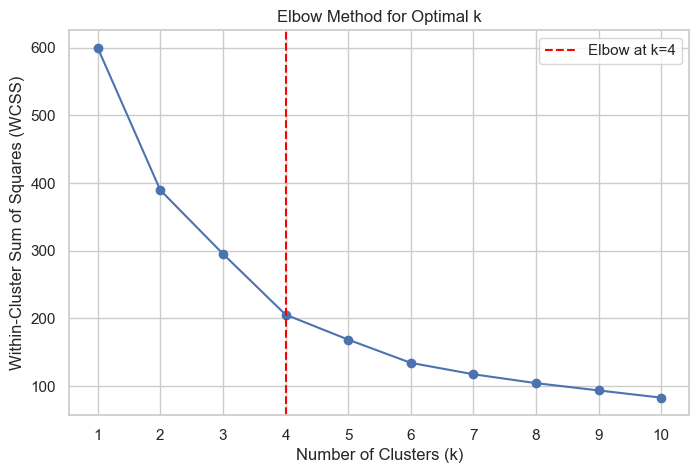

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.axvline(x=4, color='red', linestyle='--', label='Elbow at k=4')
plt.legend()
plt.show()

## Silhouette Scores

The silhouette score is a measure of what is essentially the ideal of K-means clustering: points within the same cluster should be close together, while points in different clusters should be far from each other. It is calculated with the following formula:  

$s(i) = \frac{b(i) - a(i)}{\max\{a(i),\ b(i)\}}$

In [10]:
sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

The highest silhouette score is at k=6. However this plot mirrors the previous elbow plot in the sense that it shows the most dramatic improvement is between k=3 and k=4. My interpretation is that 4, 5, or 6 would all likely be valid choices for optimal number of clusters, but in general practice 4 tends to be a good choice, and both plots seem to agree that gains begin to level off the most there. This would be something I would report to the manager, as there could potentially be some domain insight that might be applied here to further inform the decision.

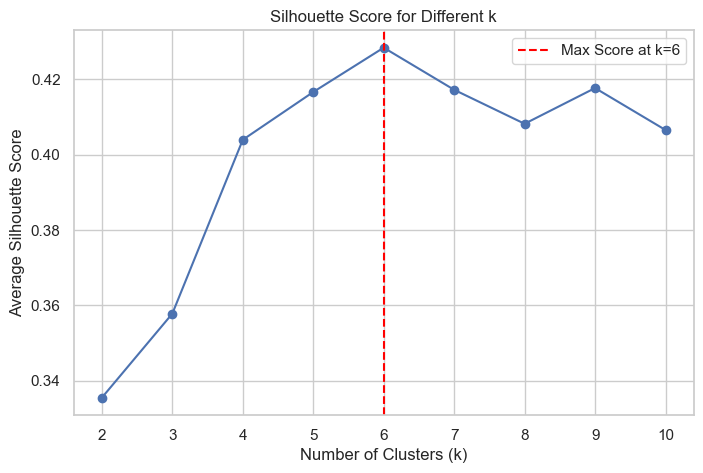

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), sil_scores, marker='o')
plt.title('Silhouette Score for Different k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True)
plt.axvline(x=6, color='red', linestyle='--', label='Max Score at k=6')
plt.legend()
plt.show()

## Final Model and Visualization

Choosing k=4 clusters we run the kmeans the same way, label each point in cluster 0, 1, 2, or 3, and then plot all three 2D space combinations of the variables, as well as a plot in principle component reduced space.

In [12]:
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
labels = kmeans.fit_predict(X_scaled)

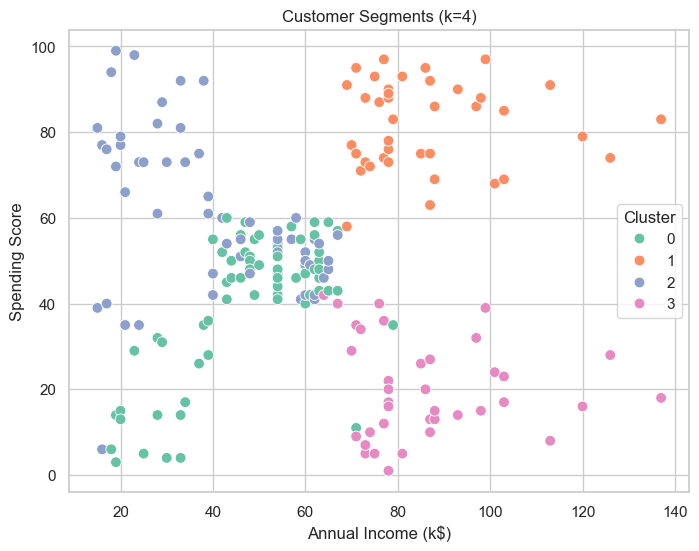

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=mall_cust_data['Annual Income (k$)'],
    y=mall_cust_data['Spending Score (1-100)'],
    hue=labels,
    palette='Set2',
    s=60
)
plt.title('Customer Segments (k=4)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

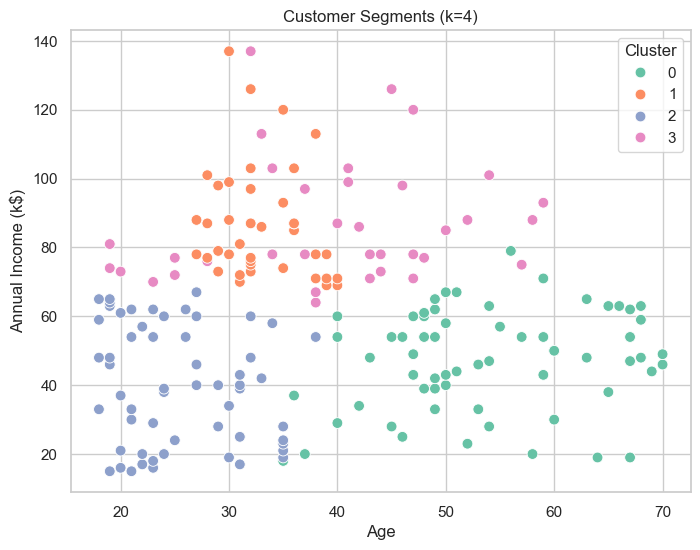

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=mall_cust_data['Age'],
    y=mall_cust_data['Annual Income (k$)'],
    hue=labels,
    palette='Set2',
    s=60
)
plt.title('Customer Segments (k=4)')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

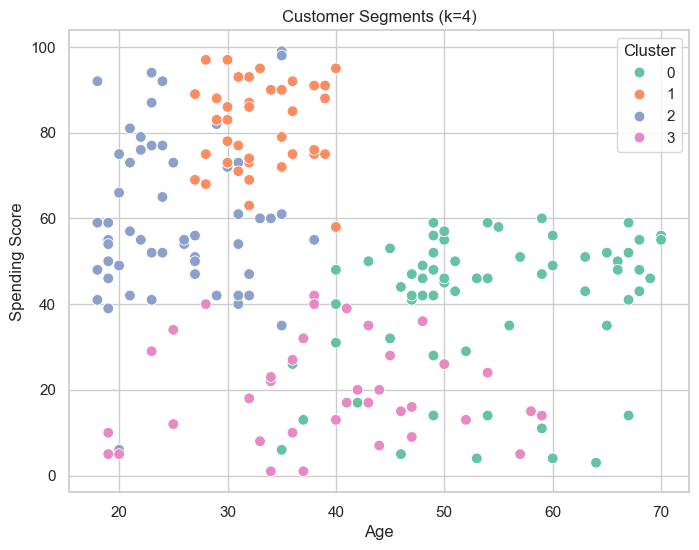

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=mall_cust_data['Age'],
    y=mall_cust_data['Spending Score (1-100)'],
    hue=labels,
    palette='Set2',
    s=60
)
plt.title('Customer Segments (k=4)')
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [ ]:
X_pca = PCA(n_components=2).fit_transform(X_scaled)

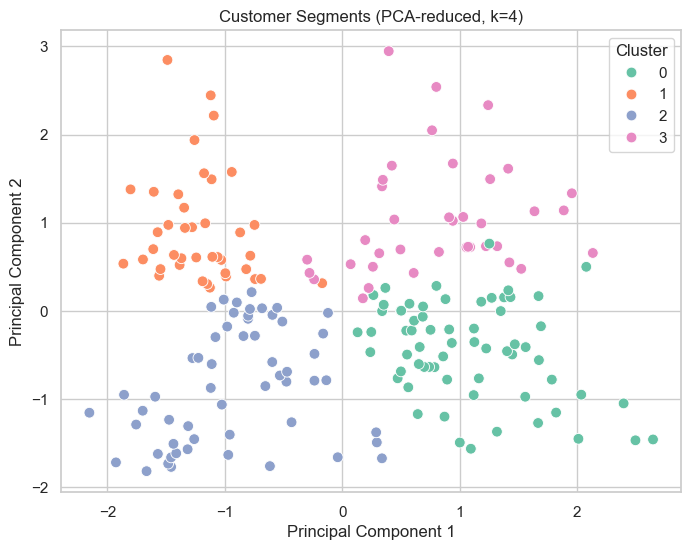

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=labels,
    palette='Set2',
    s=60
)
plt.title('Customer Segments (PCA-reduced, k=4)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

## Interpretation

After plotting all possible combinations of the variables in 2D space, I would highlight the first and last plots i.e. annual income and spending score space, as well as the principle component reduced space. These two plots are the most illuminating in regards to visualizing these 4 clusters:  

In the first plot we see the most seperation between clusters, with each cluster more or less occupying the majority of a given quadrant. The noticeable exception here however is where cluster 0 and 2 have a lot of overlap. If we take cluster 0 to be lower income and low spenders, and cluster 2 to be lower income but high spenders, we can see that in reality there are many customers in both groups that are quite similar and meet somewhere in the middle. This is rather intuitive as it suggests the closer you move from low income to middle income, spending also balances out in the middle. For higher income individuals, in this plot, it seems there is a distinct segment that spends a lot, and another distinct segment that spends much less. This suggests, between those two groups, some other variable is driving the difference between their spending behavior at the mall.  

In the second plot, all 3 variables Age, Annual Income, and Spending Score have been compressed from 3 dimensions to 2 using principle component analysis (dimensionality reduction). Here we also have a pretty nice seperation of clusters with all four tending to touch towards the center of the graph. This suggests that 4 clusters was not a bad choice, however there are certainly quite a few customers that could truly be members of two segments, i.e. they sit at the border.  

Ultimately, I would likely favor leaning on the first plot for interpreting customer segments that can be described to management. Segment 0 are lower income and low spenders. Segment 1 contains higher income and higher spenders. Segment 2 are lower income but high spenders. Finally segment 3 are higher income but low spenders. I would definitely also add the caveat explained above, that there is plenty of overlap between segment 0 and 2, suggesting there is potentially a fifth segment of middle income and middle spenders. From the other plots we might infer that Age plays a supporting role in differntiating the customer segments, but not as strong a driver as annual income and spending score. I would therefore recommend the following example marketing initiatives the management of the mall could take:  

- **Low Income + Low Spend**  
Initiative: Offer entry-level loyalty programs or bundled value deals to increase visit frequency without pressuring high spending.

- **Low Income + High Spend**  
Initiative: Target with flash sales and rewards for continued engagement.

- **High Income + High Spend**  
Initiative: Introduce premium experiences, VIP programs, or early access events — they are your core profit drivers and respond to personalized, high-status offers.

- **High Income + Low Spend**  
Initiative: Use personalized promotions or premium product sampling to increase conversion — they have capacity to spend more but need better targeting.